In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [2]:
# Load data
df = pd.read_csv('../data/creditcard.csv')

# Scale Time and Amount
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Time', 'Amount'], axis=1)

# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build and train model
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# Default threshold evaluation
y_pred = model.predict(X_test)
print("Default threshold (0.5)")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Lower threshold evaluation
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_pred_proba >= 0.3).astype(int)
print("Lower threshold (0.3)")
print(classification_report(y_test, y_pred_threshold))
print(confusion_matrix(y_test, y_pred_threshold))

# Find optimal threshold
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Best F1 score: {best_f1:.4f}")

# Evaluate with optimal threshold
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
print(f"\n--- Optimal threshold ({best_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_optimal))
print(confusion_matrix(y_test, y_pred_optimal))

# Analyse missed fraud cases
missed_fraud = X_test[(y_test == 1) & (y_pred == 0)]
caught_fraud = X_test[(y_test == 1) & (y_pred == 1)]

print(f"Missed fraud cases: {len(missed_fraud)}")
print(f"Caught fraud cases: {len(caught_fraud)}")
print("\nMissed fraud - Amount stats:")
print(missed_fraud['Amount_scaled'].describe())
print("\nCaught fraud - Amount stats:")
print(caught_fraud['Amount_scaled'].describe())

Default threshold (0.5)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56861     3]
 [   24    74]]
Lower threshold (0.3)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56859     5]
 [   18    80]]
Optimal threshold: 0.27
Best F1 score: 0.8757

--- Optimal threshold (0.27) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.83      0.88      

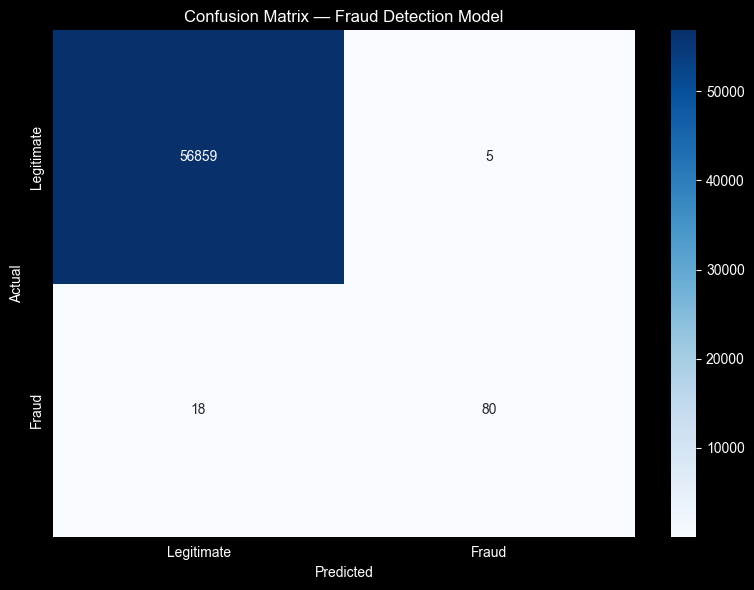

In [3]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Confusion Matrix — Fraud Detection Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

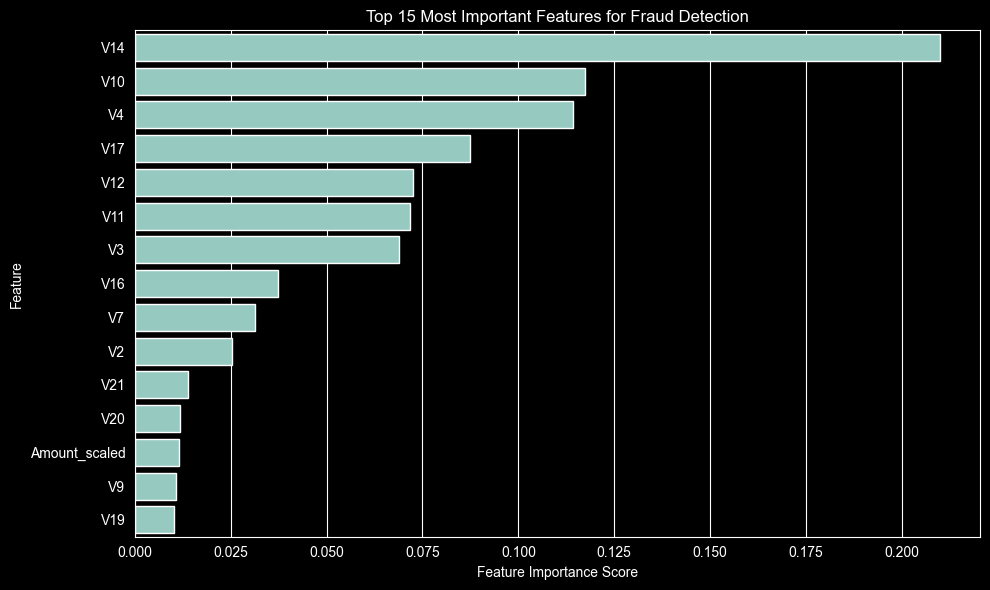

In [4]:
# Feature importance chart
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Top 15 Most Important Features for Fraud Detection')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

C:\Users\ojash\AppData\Local\Temp\ipykernel_14380\497688381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])


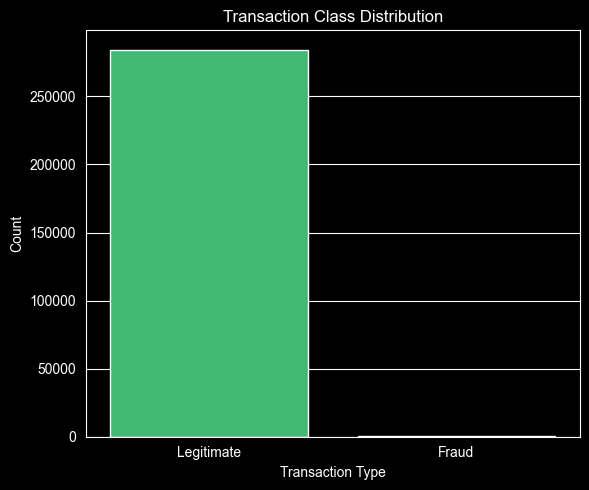

In [5]:
# Class distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Transaction Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

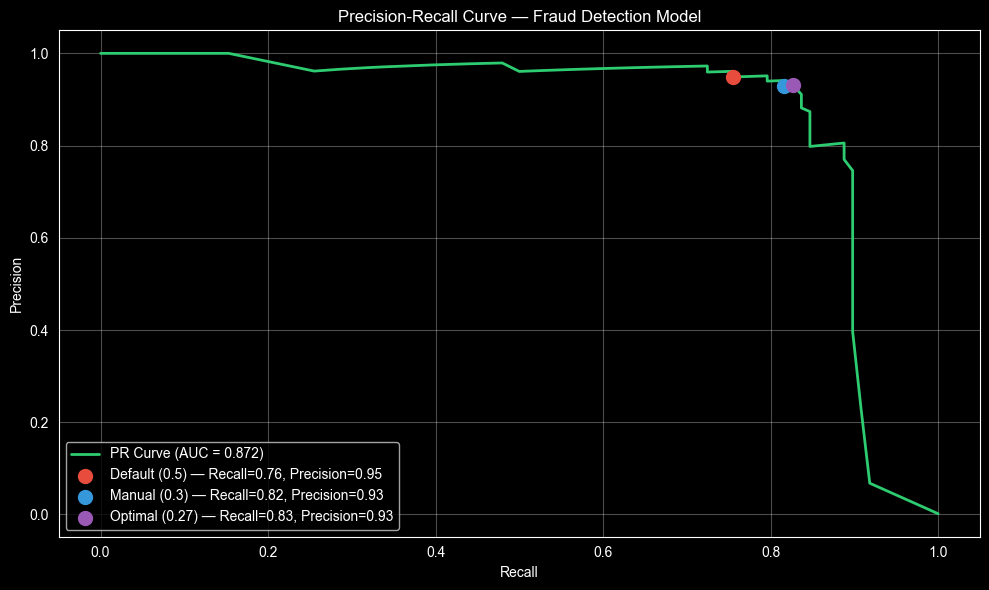

C:\Users\ojash\AppData\Local\Temp\ipykernel_14380\3738412584.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])


All images saved to images/ folder


In [11]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate precision-recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='#2ecc71', linewidth=2,
         label=f'PR Curve (AUC = {pr_auc:.3f})')

# Mark our three thresholds on the curve
for t, label, color in [
    (0.50, 'Default (0.5)', '#e74c3c'),
    (0.30, 'Manual (0.3)', '#3498db'),
    (0.27, 'Optimal (0.27)', '#9b59b6')
]:
    idx = np.argmin(np.abs(thresholds_pr - t))
    plt.scatter(recall[idx], precision[idx],
                color=color, s=100, zorder=5,
                label=f'{label} — Recall={recall[idx]:.2f}, Precision={precision[idx]:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Fraud Detection Model')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/precision_recall_curve.png')
plt.show()
plt.close()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_threshold)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — Fraud Detection Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png')
plt.close()

# Feature importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Top 15 Most Important Features for Fraud Detection')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../images/feature_importance.png')
plt.close()

# Class distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Transaction Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/class_distribution.png')
plt.close()

print("All images saved to images/ folder")